In [126]:
# import basic libraries
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt

# import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline 
from imblearn.pipeline import make_pipeline as imb_make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold


# import necessary functions and options
import sys
import os

sys.path.append(os.path.abspath('..'))
import my_utils as mu

from sklearn import set_config

set_config(transform_output = 'pandas')


# **Project 4 - Part 1**

* ### Choose a dataset

In [127]:
# df_featured_baseline 
df_raw = pd.read_csv('adult-income.csv')

# import the dataset 
df = df_raw.copy()

# run the head()
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


# Simple `EDA` analysis 

* ### Explore/Clean the data

In [128]:
# check the info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [129]:
# check null values
df.isnull().sum().sum()

np.int64(0)

In [130]:
# check the duplicates
df.duplicated().sum()

np.int64(52)

In [131]:
# remove the duplicates
df = df.drop_duplicates()

# check the duplicates again
df.duplicated().sum()

np.int64(0)

# Inspect every **`column`**

* ### Exploratory Visulaizations

In [132]:
# check the age column 
mu.profile_column(df, 'age', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,74 — High
Skewness,0.556582


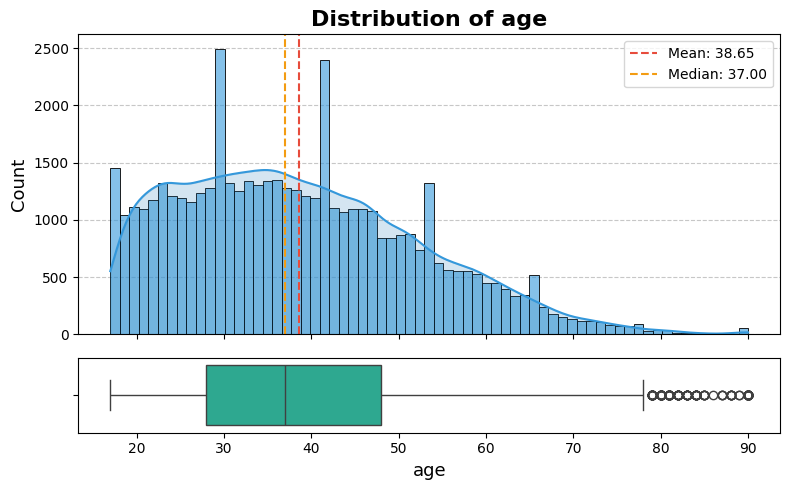

In [133]:
# plot univariate analysis for age'
mu.plot_univariate_analysis(df, 'age', figsize = (8, 5), bins = 67)


In [134]:
# check the workclass column
mu.profile_column(df, 'workclass')


,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,9 — Low
Skewness,N/A
,count
workclass,
Private,33860
Self-emp-not-inc,3861


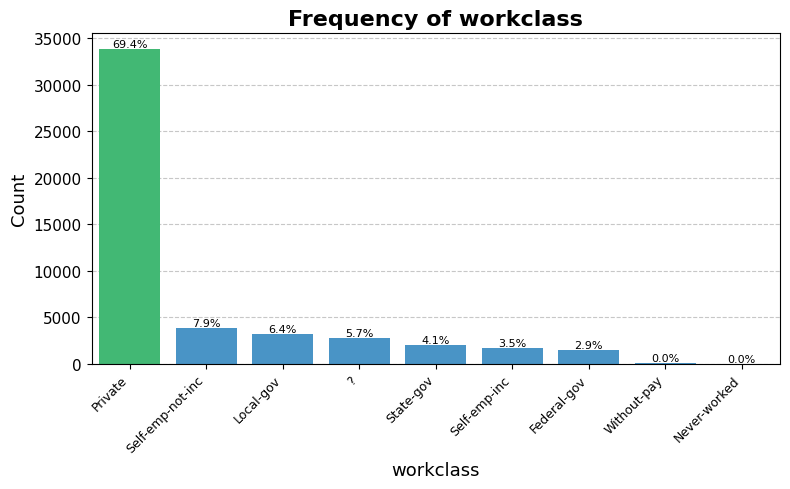

In [135]:
# plot univariate analysis for workclass 
mu.plot_univariate_analysis(df, 'workclass', figsize = (8, 5))

---

In [136]:
# check the education column
mu.profile_column(df, 'education')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,16 — Medium
Skewness,N/A
,count
education,
HS-grad,15770
Some-college,10863


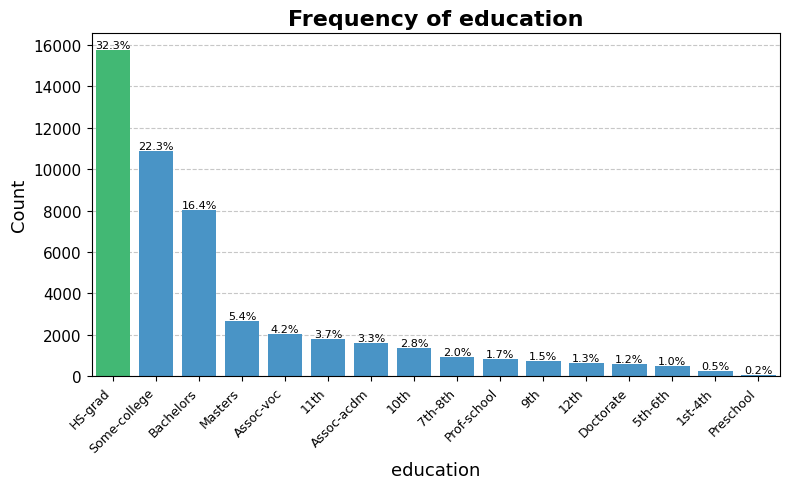

In [137]:
# plot univariate analysis for educatoin 
mu.plot_univariate_analysis(df, 'education', figsize = (8, 5))

---

In [138]:
# check the fnlwgt column 
mu.profile_column(df, 'fnlwgt', show_value_counts = False)


,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,28523 — High
Skewness,1.439698


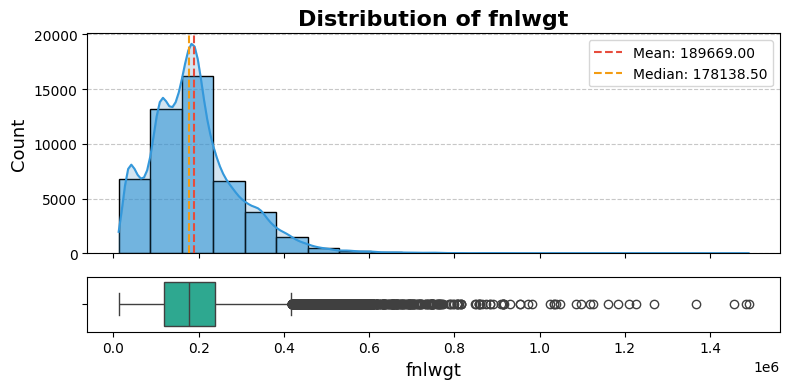

In [139]:
# plot univariate analysis for fnlwgt 
mu.plot_univariate_analysis(df, 'fnlwgt')

In [140]:
# check the educational-num column
mu.profile_column(df, 'educational-num', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,16 — Medium
Skewness,-0.314229


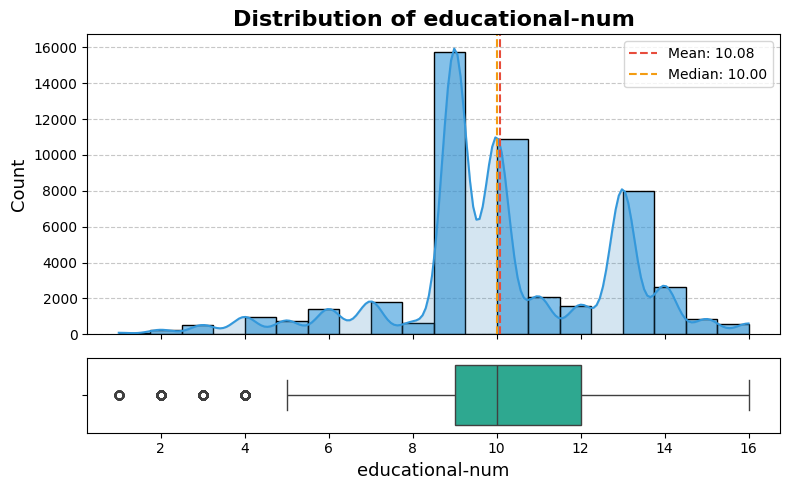

In [141]:
# plot univariate analysis for educational-num
mu.plot_univariate_analysis(df, 'educational-num', figsize=(8, 5))

In [142]:
# check the marital-status column
mu.profile_column(df, 'marital-status')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,7 — Low
Skewness,N/A
,count
marital-status,
Married-civ-spouse,22366
Never-married,16082


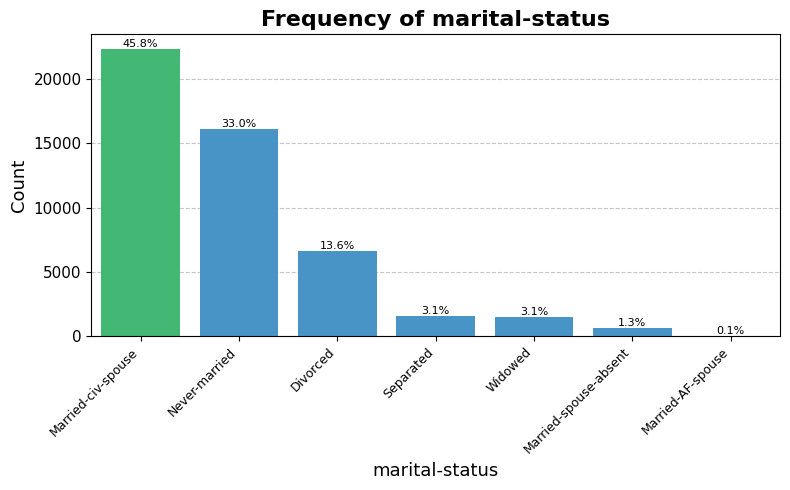

In [143]:
# plot univariate analysis for marital-status
mu.plot_univariate_analysis(df, 'marital-status', figsize=(8, 5))

In [144]:
# check the occupation column
mu.profile_column(df, 'occupation')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,15 — Medium
Skewness,N/A
,count
occupation,
Prof-specialty,6165
Craft-repair,6102


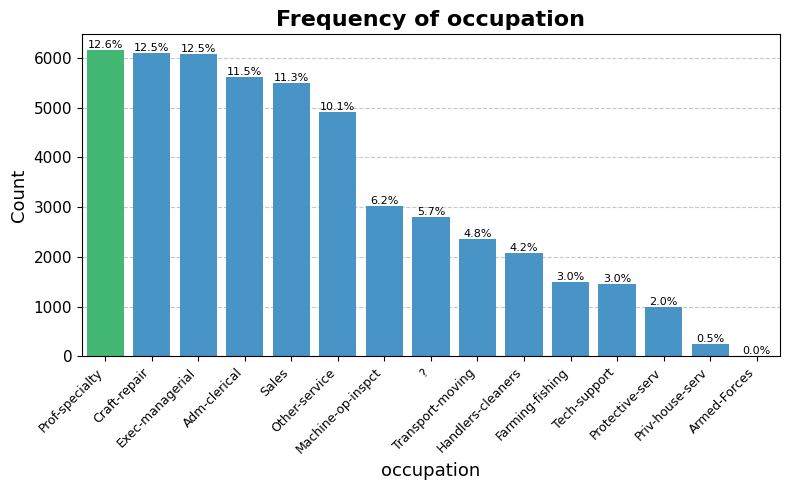

In [145]:
# plot univariate analysis for occupation
mu.plot_univariate_analysis(df, 'occupation', figsize=(8, 5))

In [146]:
# check the relationship column
mu.profile_column(df, 'relationship')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,6 — Low
Skewness,N/A
,count
relationship,
Husband,19703
Not-in-family,12557


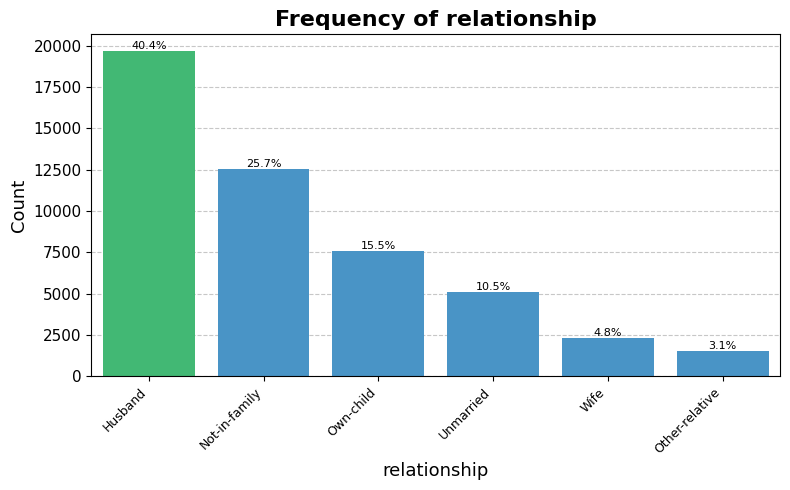

In [147]:
# plot univariate analysis for relationship
mu.plot_univariate_analysis(df, 'relationship', figsize=(8, 5))

In [148]:
# check the race column
mu.profile_column(df, 'race')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,5 — Low
Skewness,N/A
,count
race,
White,41714
Black,4683


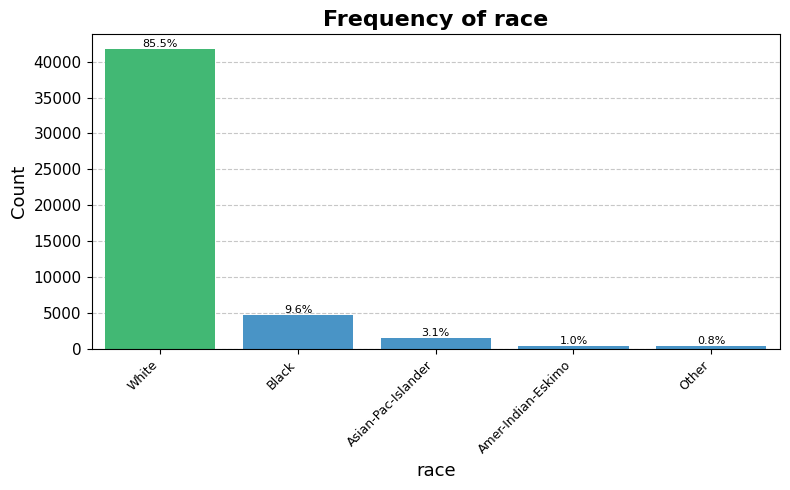

In [149]:
# plot univariate analysis for race
mu.plot_univariate_analysis(df, 'race', figsize=(8, 5))

In [150]:
# check the gender column
mu.profile_column(df, 'gender')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,2 — Low
Skewness,N/A
,count
gender,
Male,32614
Female,16176


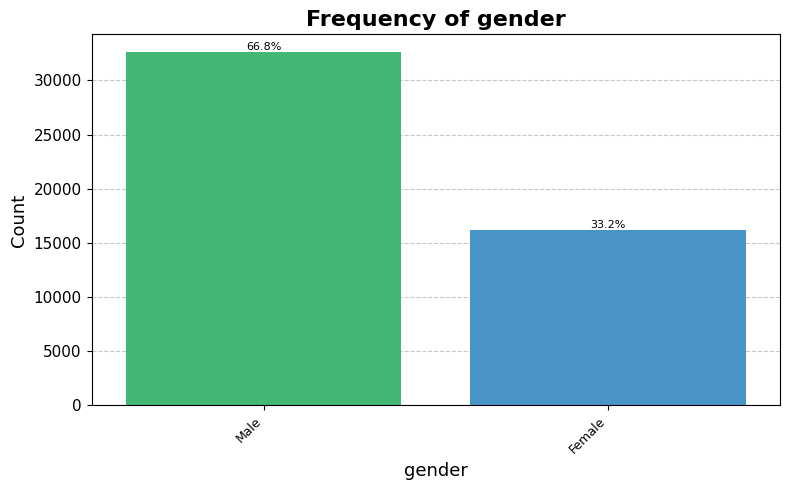

In [151]:
# plot univariate analysis for gender
mu.plot_univariate_analysis(df, 'gender', figsize=(8, 5))

In [152]:
# check the capital-gain column
mu.profile_column(df, 'capital-gain', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,123 — High
Skewness,11.888265


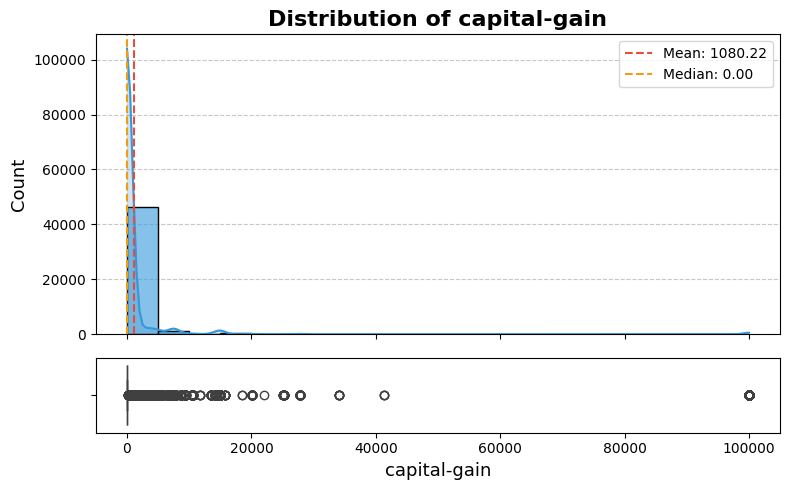

In [153]:
# plot univariate analysis for capital-gain
mu.plot_univariate_analysis(df, 'capital-gain', figsize=(8, 5))

In [154]:
# check the capital-loss column
mu.profile_column(df, 'capital-loss', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Quasi-constant
Cardinality,99 — High
Skewness,4.567037


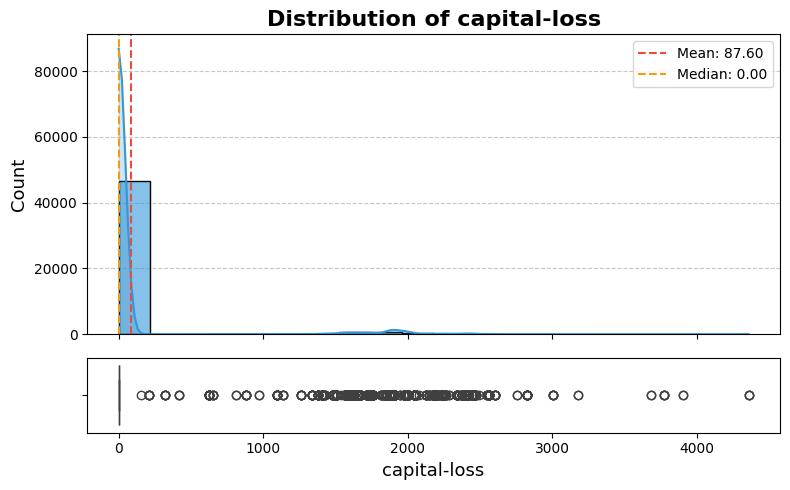

In [155]:
# plot univariate analysis for capital-loss
mu.plot_univariate_analysis(df, 'capital-loss', figsize=(8, 5))

In [156]:
# check the hours-per-week column
mu.profile_column(df, 'hours-per-week', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,96 — High
Skewness,0.239652


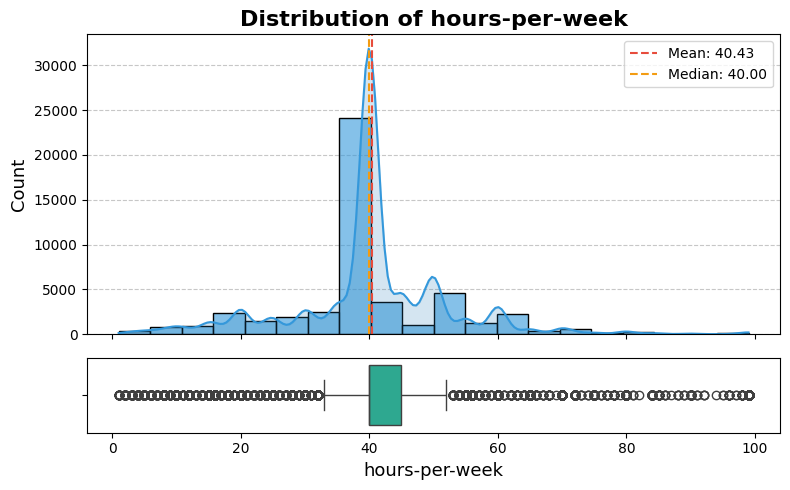

In [157]:
# plot univariate analysis for hours-per-week
mu.plot_univariate_analysis(df, 'hours-per-week', figsize=(8, 5))

In [158]:
# check the native-country column
mu.profile_column(df, 'native-country', show_value_counts = False)

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,42 — Medium
Skewness,N/A


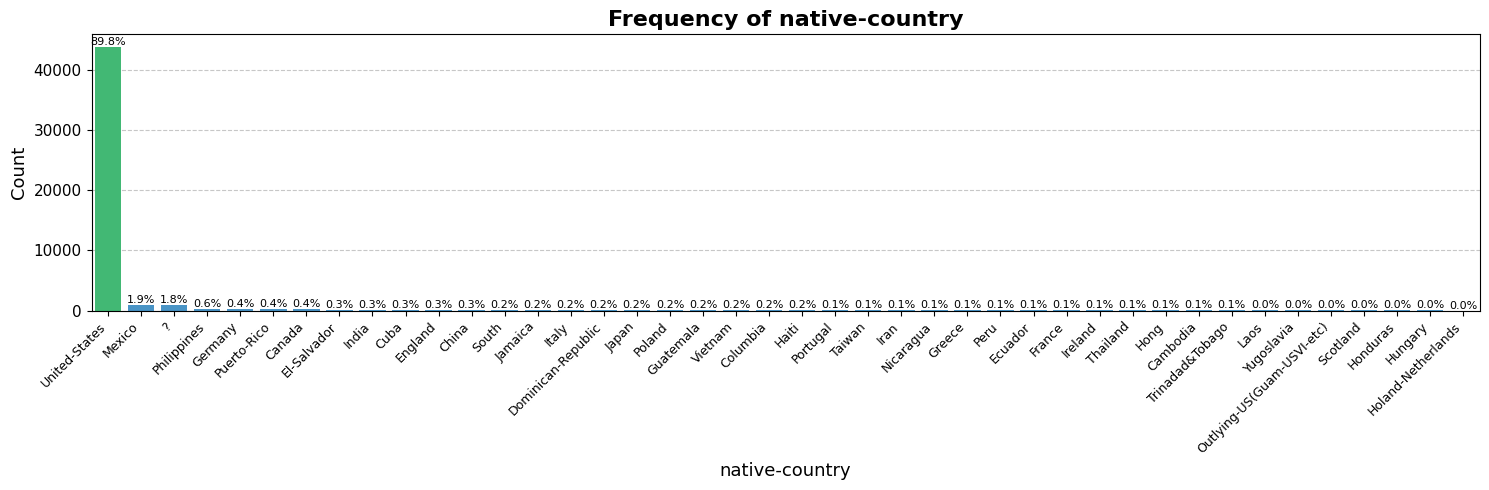

In [159]:
# plot univariate analysis for native-country
mu.plot_univariate_analysis(df, 'native-country', figsize=(15, 5))

In [160]:
# check the income column
mu.profile_column(df, 'income')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,2 — Low
Skewness,N/A
,count
income,
<=50K,37109
>50K,11681


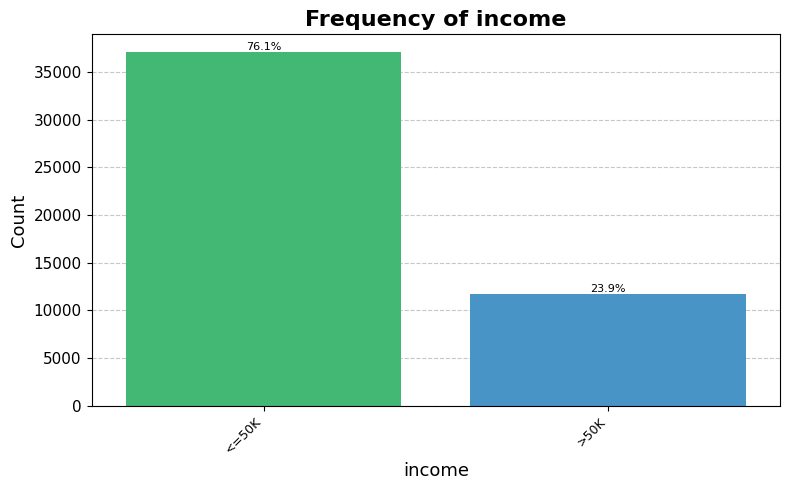

In [161]:
# plot univariate analysis for income
mu.plot_univariate_analysis(df, 'income', figsize=(8, 5))

---

# Part 1 — Baseline Model (no feature engineering)

* ### Choose a model

In [162]:
# copy data from raw dataframe
df_baseline = df_raw.copy()

# run the dataframe
df_baseline.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


# Preprocess: Baseline (no feature engineering)


* ### Preprocess the data

In [163]:
# y_base target 
y_base = df_baseline['income']

# X_base features
X_base = df_baseline.drop(columns=['income', 'fnlwgt'])

# train test split the model
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, random_state=43, stratify=y_base)

X_train_base.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
43271,23,Private,Assoc-voc,11,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States
24741,29,Private,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,United-States
24784,37,Private,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States
15512,35,Private,Bachelors,13,Divorced,Transport-moving,Not-in-family,White,Male,0,0,40,United-States
4664,37,Private,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States


In [164]:
# baseline model column transformer
col_transformer_base = ColumnTransformer(transformers=[
    ('Numerical', SimpleImputer(strategy='median'), X_train_base.select_dtypes('number').columns),
    ('Categorical', make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    ), X_train_base.select_dtypes('str').columns)
], verbose_feature_names_out=False)

col_transformer_base

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical', ...), ('Categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

# `RandomForest` — **Baseline (no feature engineering)**

* ### fit and evaluate a defualt model

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.98      0.99      0.98     27866
        >50K       0.96      0.94      0.95      8765

    accuracy                           0.97     36631
   macro avg       0.97      0.96      0.97     36631
weighted avg       0.97      0.97      0.97     36631



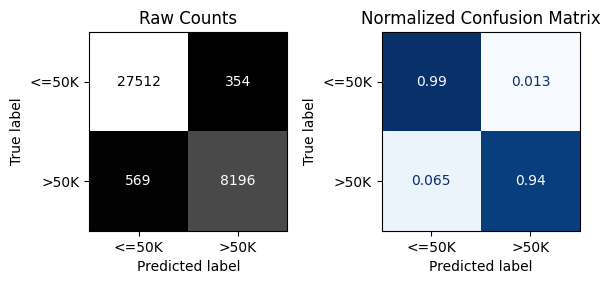


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      9289
        >50K       0.72      0.64      0.68      2922

    accuracy                           0.85     12211
   macro avg       0.81      0.78      0.79     12211
weighted avg       0.85      0.85      0.85     12211



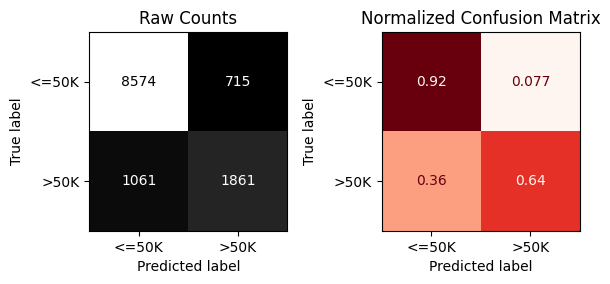

In [165]:
# initiate RandomForest
rf_base = RandomForestClassifier(random_state = 43)

# create pipeline
rf_base_pipe = make_pipeline(col_transformer_base, rf_base)

# fit the model 
rf_base_pipe.fit(X_train_base, y_train_base)

# run metrics 
mu.evaluate_classification(rf_base_pipe, X_train_base, y_train_base, X_test_base, y_test_base)

* ### Extract and visualize the top 10 features using permutation importance

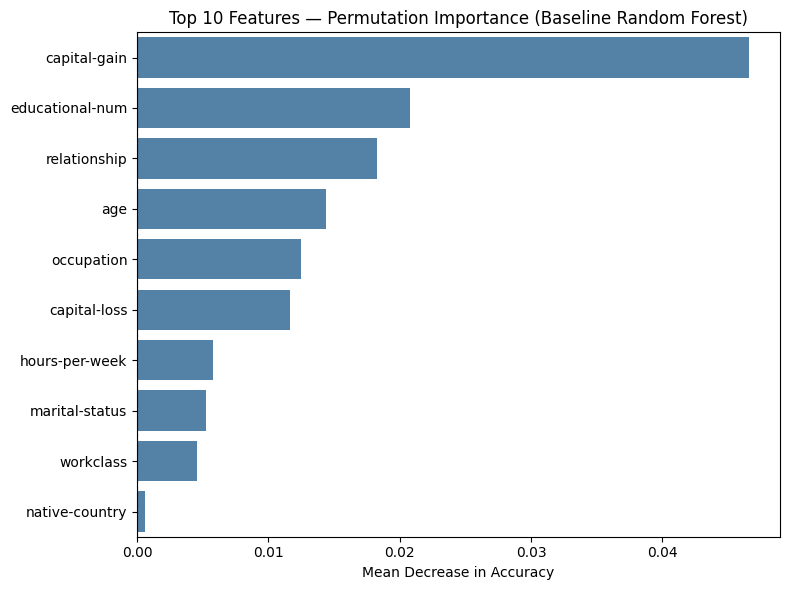

In [166]:
perm_result_base = permutation_importance(
    rf_base_pipe, X_test_base, y_test_base,
    n_repeats=10, random_state=43, n_jobs=1
)

perm_df_base = pd.DataFrame({
    'feature':         X_test_base.columns,
    'importance_mean': perm_result_base.importances_mean,
    'importance_std':  perm_result_base.importances_std
}).sort_values('importance_mean', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=perm_df_base, x='importance_mean', y='feature', ax=ax, color='steelblue')
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_ylabel('')
ax.set_title('Top 10 Features — Permutation Importance (Baseline Random Forest)')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

* ### Do These Features Make Sense Based on the Business Case?

Yes, the top features align well with what we'd expect when predicting whether
someone earns more or less than $50K per year:

- **capital-gain** is by far the most important feature — individuals who earn
  investment income are strongly associated with higher overall wealth, making
  this a logical predictor.
- **relationship** and **marital-status** reflect household financial dynamics;
  married individuals (especially "Husband") tend to have higher reported incomes
  in this dataset.
- **educational-num** and **occupation** directly reflect earning potential —
  higher education and professional roles are well-known drivers of higher salaries.
- **age** captures career progression; income generally increases with experience
  over time.
- **hours-per-week** and **capital-loss** are reasonable proxies for work
  commitment and active investment activity, respectively.

Overall, these features reflect real-world socioeconomic factors, lending
credibility to the model's learned patterns.

# Create Explanatory Visualizations for the most important features.
* ### Select 2 out of the top 10 features from your permutation importances and produce explanatory visualizations showing the relationship between the feature and the target.

## Feature Selection Rationale

I selected **`age`** and **`educational-num`** because they tell the clearest,
most intuitive stories for a non-technical audience. Age captures career
progression over time, while education level directly reflects earning potential
— both are universally understood concepts that stakeholders can immediately
relate to and act on.

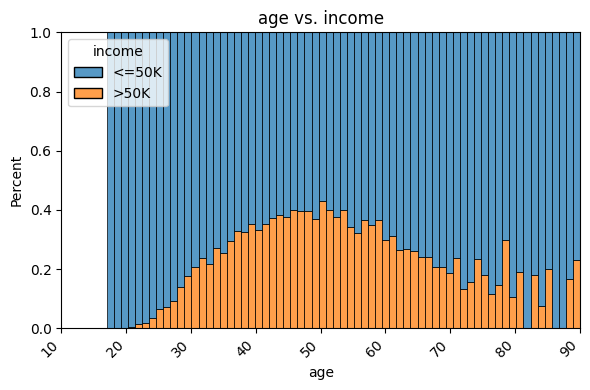

In [167]:
# relationship between age and target
mu.plot_categorical_vs_categorical(df, 'age', 'income');

## Insight: Age and Income

People in their **40s and 50s** are the most likely to earn over $50K per year,
with the proportion peaking around age 45–55. Younger people (under 30) and
older people (over 65) are far less likely to fall in the higher income bracket.
This suggests that **mid-career professionals represent the highest-earning
segment** of the workforce.

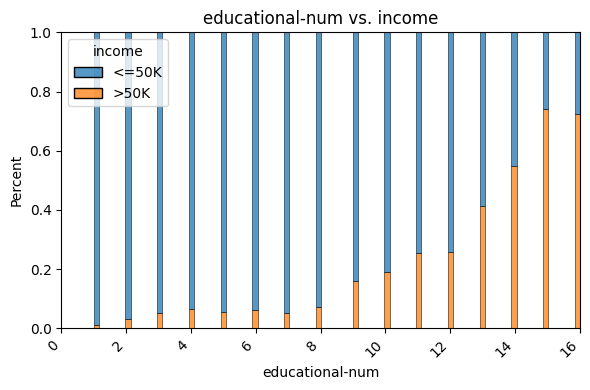

In [168]:
# relationship between educational-num and target
mu.plot_categorical_vs_categorical(df, 'educational-num', 'income');

## Insight: Education Level and Income

There is a **clear, consistent relationship** between education level and income.
People with lower educational attainment (levels 1–8, roughly below high school
to some high school) have almost **no chance** of earning over $50K. However,
starting from level 13 (Bachelor's degree and above), the proportion earning
over $50K rises sharply — reaching nearly **75% at the highest education levels**
(Master's and Doctorate degrees).

This confirms that **higher education is one of the strongest predictors of
earning above $50K**, making it a highly meaningful feature for this model.

---

# **Project 4 - Part 2**

In [169]:
# copy the raw data
df = df_raw.copy()

# run df
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


* ### Choose at least one feature engineering method to apply to the data and compare the models’  performance with and without engineering.
> - PCA
> - KMeans 
> - Feature Engineerinig


In [170]:
# y target 
y = df['income']

# X features
X = df.drop(columns=['income', 'fnlwgt'])

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 43, stratify = y)

In [171]:
# column transformer for PCA
col_transformer_pca = ColumnTransformer(transformers=[
    ('Numerical', make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler()
    ), X_train.select_dtypes('number').columns),
    ('Categorical', make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    ), X_train.select_dtypes('str').columns)
], verbose_feature_names_out=False)

In [172]:
# fit column transformer on train then transform both
X_train_tr = col_transformer_pca.fit_transform(X_train)
X_test_tr = col_transformer_pca.transform(X_test)

In [173]:
# initialize PCA 
pca = PCA(n_components = 3, random_state = 43)

# fit pca
pca_train = pca.fit_transform(X_train_tr)
pca_test  = pca.transform(X_test_tr)

In [174]:
# create a dataframe from X_train
X_train_final = pd.concat([X_train_tr.reset_index(drop=True), pca_train.reset_index(drop=True)], axis=1)

# creaete a dataframe from X_test
X_test_final = pd.concat([X_test_tr.reset_index(drop=True), pca_test.reset_index(drop=True)], axis=1)


In [175]:
# finalize y_train
y_train_final = y_train.reset_index(drop=True)

# finalize y_test
y_test_final  = y_test.reset_index(drop=True)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.98      0.99      0.98     27866
        >50K       0.96      0.93      0.95      8765

    accuracy                           0.97     36631
   macro avg       0.97      0.96      0.97     36631
weighted avg       0.97      0.97      0.97     36631



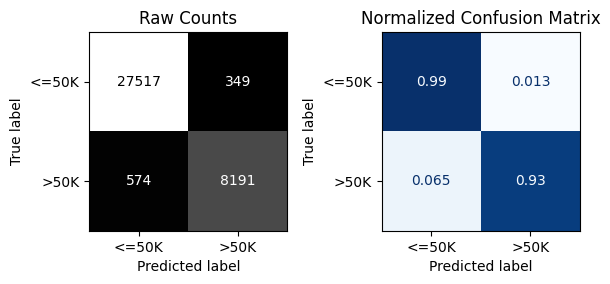


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      9289
        >50K       0.71      0.64      0.67      2922

    accuracy                           0.85     12211
   macro avg       0.80      0.78      0.79     12211
weighted avg       0.85      0.85      0.85     12211



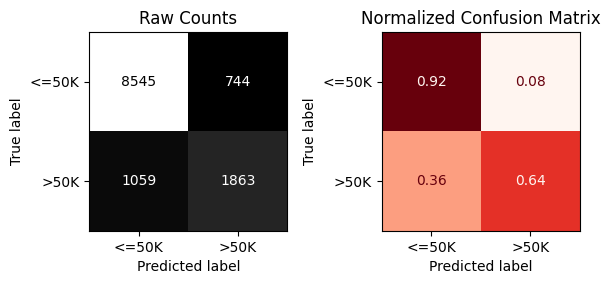

In [176]:
# initialize RandomForest
rf_pca = RandomForestClassifier(random_state=43)

# fit the model
rf_pca.fit(X_train_final, y_train_final)

# evaluate the model
mu.evaluate_classification(rf_pca, X_train_final, y_train_final, X_test_final, y_test_final)

* ### Fit and evaluate a model using your new features and compare it to your model from Part 1.

## Model Comparison: Baseline vs PCA

| Metric          | Baseline | PCA (3 components) |
|-----------------|----------|--------------------|
| Accuracy        | 0.86     | 0.86               |
| >50K Precision  | 0.76     | 0.74               |
| >50K Recall     | 0.63     | 0.62               |
| >50K F1-score   | 0.69     | 0.68               |

Applying PCA **did not** improve the model. Adding 3 principal components to the
original 14 features introduced redundant information that the Random Forest
was already capturing from the original features directly.

* ### Apply at least one method of feature selection (filtering, embedded, wrapper) to your new features including engineered data.
> * Filtering using: **Variance**

In [177]:
# initialize VarianceThreshold
selector = VarianceThreshold(threshold=0.1)

# fit transform data 
X_train_selected = selector.fit_transform(X_train_final)
X_test_selected  = selector.transform(X_test_final)

In [178]:
# check how many features were kept
print("Before:", X_train_final.shape[1])
print("After: ", X_train_selected.shape[1])

Before: 16
After:  16


* ### Fit and evaluate a final model using the selected features. Compare it with previous models

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.98      0.99      0.98     27866
        >50K       0.96      0.93      0.95      8765

    accuracy                           0.97     36631
   macro avg       0.97      0.96      0.97     36631
weighted avg       0.97      0.97      0.97     36631



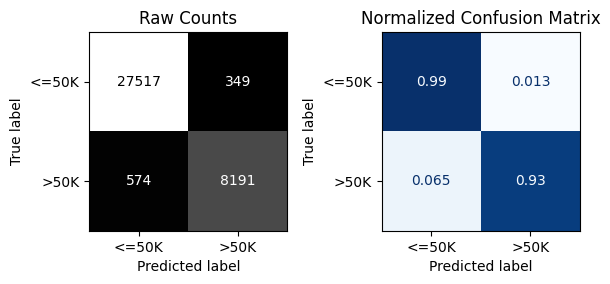


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      9289
        >50K       0.71      0.64      0.67      2922

    accuracy                           0.85     12211
   macro avg       0.80      0.78      0.79     12211
weighted avg       0.85      0.85      0.85     12211



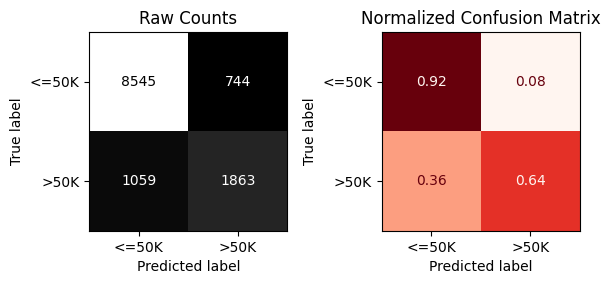

In [179]:
# initialize the model
rf_selected = RandomForestClassifier(random_state=43)

# fit the model
rf_selected.fit(X_train_selected, y_train_final)

# run evaluation metrics
mu.evaluate_classification(rf_selected, X_train_selected, y_train_final, X_test_selected, y_test_final)

## Model Comparison: All Models

| Metric          | Baseline | PCA + Original | After Feature Selection |
|-----------------|----------|----------------|------------------------|
| Accuracy        | **0.86** | 0.86           | 0.86                   |
| >50K Precision  | **0.76** | 0.74           | 0.74                   |
| >50K Recall     | **0.63** | 0.62           | 0.62                   |
| >50K F1-score   | **0.69** | 0.68           | 0.68                   |

Feature selection using `VarianceThreshold` did not improve the model — it removed
no meaningful features from the PCA dataset, resulting in identical performance.
The baseline model remains the best performer across all metrics.

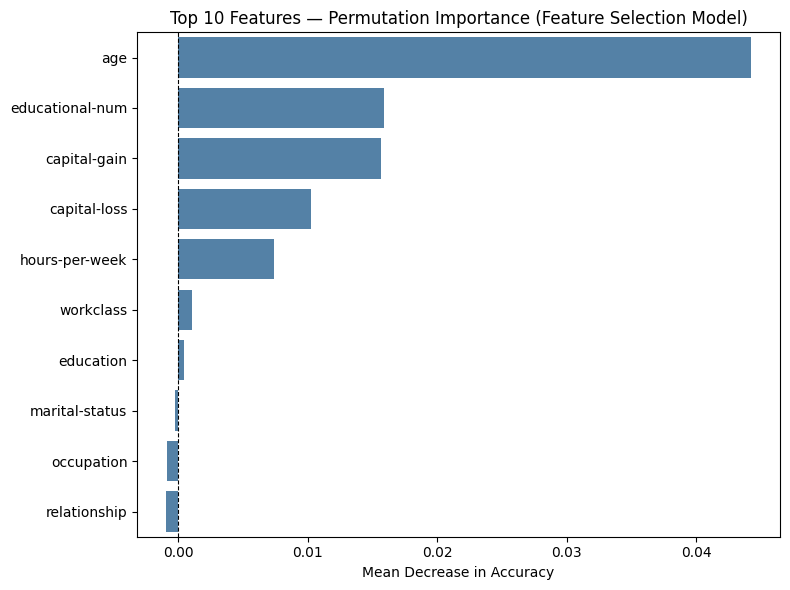

In [180]:
perm_result = permutation_importance(
    rf_selected, X_test_selected, y_test_final,
    n_repeats=10, random_state=43, n_jobs=1
)

perm_df = pd.DataFrame({
    'feature':         range(X_test_selected.shape[1]),
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std
}).sort_values('importance_mean', ascending=False).head(10)

feature_names = X_train_final.columns[selector.get_support()].tolist()
perm_df['feature'] = feature_names[:len(perm_df)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=perm_df, x='importance_mean', y='feature', ax=ax, color='steelblue')
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_ylabel('')
ax.set_title('Top 10 Features — Permutation Importance (Feature Selection Model)')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')



plt.tight_layout()
plt.show()

## Feature Selection: Observations

After applying `VarianceThreshold` on the concatenated dataset (original features + PCs),
the feature rankings shifted noticeably compared to the baseline:

- **`age`** jumped to #1 from #4, becoming the most important feature
- **`capital-gain`** dropped to #3 from #1
- **`relationship`** dropped to #10 from #2
- **`fnlwgt`** dropped out of the top 10 entirely
- **`education`** appeared as a new entry in the top 10

Despite these shifts in feature importance, the model performance did not improve
over the baseline. `VarianceThreshold` removed no meaningful features, suggesting
that all features carried sufficient variance to be retained. The baseline model
remains the strongest performer overall.